In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time
import glob
import os

In [3]:
# we want to see if we can get data in from a csv

In [14]:
testDF = pd.read_csv('../SDCardOut/dos/26033020.CSV')
testDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260330_201540_000,72940.000,4159.9746,N,8739.3770,W,543
1,260330_201540_430,72940.430,4159.9746,N,8739.3770,W,497
2,260330_201540_529,72940.531,4159.9746,N,8739.3770,W,458
3,260330_201540_629,72940.633,4159.9746,N,8739.3770,W,427
4,260330_201540_729,72940.727,4159.9746,N,8739.3770,W,401
...,...,...,...,...,...,...,...
800,260330_201700_300,73020.297,4159.9844,N,8739.4414,W,347
801,260330_201700_400,73020.398,4159.9844,N,8739.4414,W,347
802,260330_201700_500,73020.500,4159.9844,N,8739.4414,W,346
803,260330_201700_600,73020.602,4159.9844,N,8739.4414,W,347


In [4]:
timecodeArr = np.array(testDF['timecode'])
timecodeArr
len(timecodeArr)

805

In [5]:
sensorArr = np.array(testDF['sensor'])
sensorArr
len(sensorArr)

805

In [6]:
timeseries = np.arange(0,80.5,0.1)

Text(0, 0.5, 'sensor value')

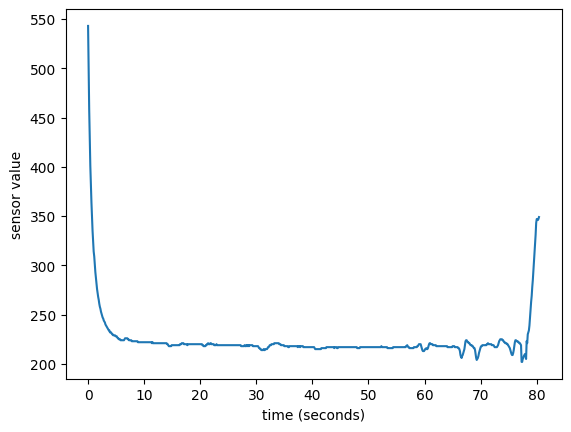

In [7]:
plt.plot(timeseries,sensorArr)
plt.xlabel('time (seconds)')
plt.ylabel('sensor value')

In [32]:
voltageArr = sensorArr * 5/16383

Text(0, 0.5, 'voltage value')

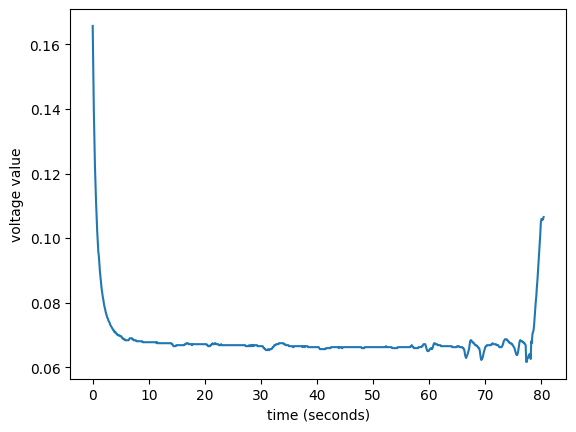

In [33]:
plt.plot(timeseries,voltageArr)
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

Text(0, 0.5, 'voltage value')

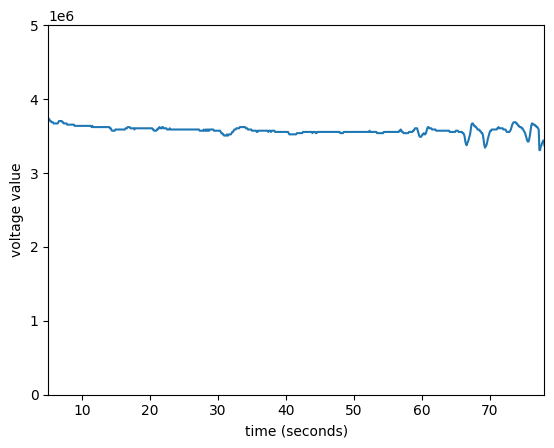

In [30]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0,5000000)
#plt.ylim(0,ymax + 1000000)
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

Text(0, 0.5, 'voltage value')

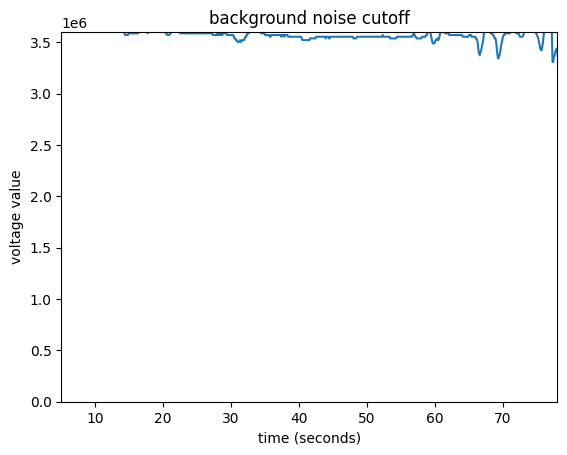

In [31]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0, 3600000)
#plt.ylim(0, ycutoff)
plt.title('background noise cutoff')
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

In [ ]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0, 3600000)
#plt.ylim(ycutoff, ymax +1000000)
plt.title('train event cutoff')
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

In [10]:
freqpsd10,powpsd10 = sp.signal.welch(sensorArr,fs=10,nperseg=10)
freqpsd50,powpsd50 = sp.signal.welch(sensorArr,fs=10,nperseg=50)
freqpsd100,powpsd100 = sp.signal.welch(sensorArr,fs=10,nperseg=100)
freqpsd500,powpsd500 = sp.signal.welch(sensorArr,fs=10,nperseg=500)

[]

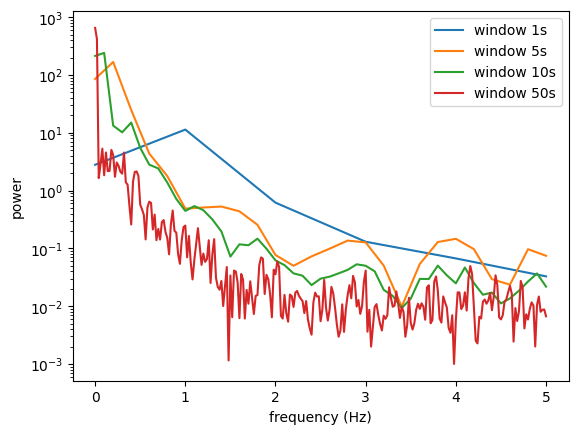

In [11]:
plt.plot(freqpsd10,powpsd10,label="window 1s")
plt.plot(freqpsd50,powpsd50,label="window 5s")
plt.plot(freqpsd100,powpsd100,label="window 10s")
plt.plot(freqpsd500,powpsd500,label="window 50s")
plt.xlabel('frequency (Hz)')
plt.ylabel("power")
plt.legend()
plt.semilogy()

In [12]:
#ok